In [ ]:
!pip install mlxtend

In [25]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
df = pd.read_csv('groceries - groceries.csv')

df.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
print(df.shape)


(9835, 33)


In [18]:

print(df.columns)


Index(['Item(s)', 'Item 1', 'Item 2', 'Item 3', 'Item 4', 'Item 5', 'Item 6',
       'Item 7', 'Item 8', 'Item 9', 'Item 10', 'Item 11', 'Item 12',
       'Item 13', 'Item 14', 'Item 15', 'Item 16', 'Item 17', 'Item 18',
       'Item 19', 'Item 20', 'Item 21', 'Item 22', 'Item 23', 'Item 24',
       'Item 25', 'Item 26', 'Item 27', 'Item 28', 'Item 29', 'Item 30',
       'Item 31', 'Item 32'],
      dtype='object')


In [19]:

print(df.isnull().sum())

Item(s)       0
Item 1        0
Item 2     2159
Item 3     3802
Item 4     5101
Item 5     6106
Item 6     6961
Item 7     7606
Item 8     8151
Item 9     8589
Item 10    8939
Item 11    9185
Item 12    9367
Item 13    9484
Item 14    9562
Item 15    9639
Item 16    9694
Item 17    9740
Item 18    9769
Item 19    9783
Item 20    9797
Item 21    9806
Item 22    9817
Item 23    9821
Item 24    9827
Item 25    9828
Item 26    9828
Item 27    9829
Item 28    9830
Item 29    9831
Item 30    9834
Item 31    9834
Item 32    9834
dtype: int64


In [20]:
# Basic information
print("Total Transactions:", df.shape[0])
print("Total Columns:", df.shape[1])

# Unique items
items = set()

for col in df.columns[1:]:
    items.update(df[col].dropna().unique())

print("Total Unique Items:", len(items))
print("\nSome Items:")
print(list(items)[:20])

Total Transactions: 9835
Total Columns: 33
Total Unique Items: 169

Some Items:
['softener', 'frozen chicken', 'specialty vegetables', 'berries', 'cling film/bags', 'bottled water', 'yogurt', 'hygiene articles', 'semi-finished bread', 'canned vegetables', 'liquor', 'salad dressing', 'whisky', 'canned fish', 'bottled beer', 'meat spreads', 'canned fruit', 'baby cosmetics', 'cat food', 'pasta']


In [21]:
from collections import Counter

# Count frequency of each item
item_counts = Counter()

for col in df.columns[1:]:
    for item in df[col].dropna():
        item_counts[item] += 1

# Top 10 most purchased items
top_10 = item_counts.most_common(10)

print("Top 10 Most Purchased Items:")
for item, count in top_10:
    print(f"{item}: {count}")

Top 10 Most Purchased Items:
whole milk: 2513
other vegetables: 1903
rolls/buns: 1809
soda: 1715
yogurt: 1372
bottled water: 1087
root vegetables: 1072
tropical fruit: 1032
shopping bags: 969
sausage: 924


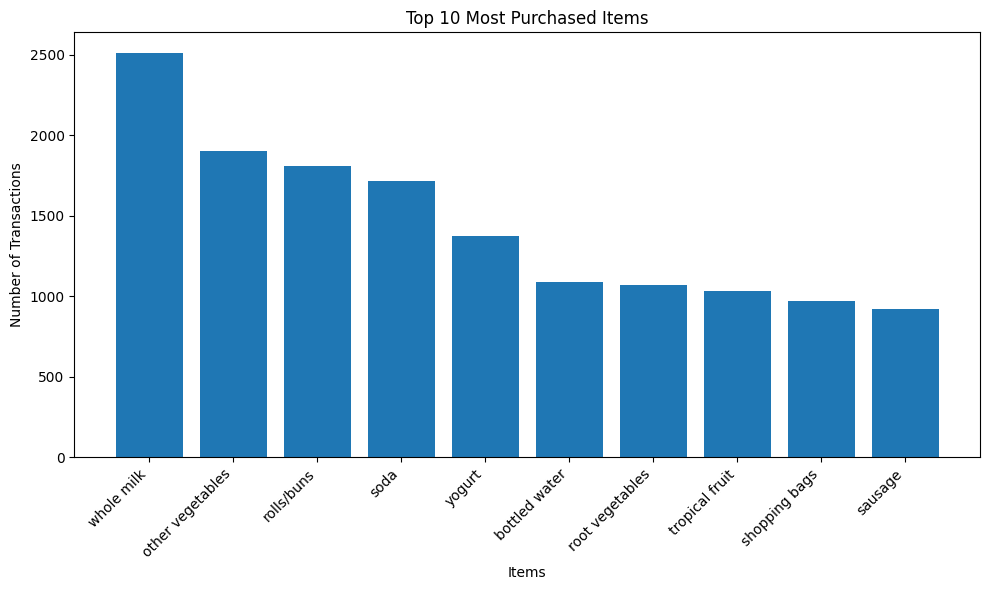

In [22]:
items = [item for item, count in top_10]
counts = [count for item, count in top_10]

plt.figure(figsize=(10, 6))
plt.bar(items, counts)

plt.title("Top 10 Most Purchased Items")
plt.xlabel("Items")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [27]:
# Create basket using a faster method

basket = pd.get_dummies(
    df.iloc[:, 1:].stack()
).groupby(level=0).max().astype(int)

print("Basket Shape:", basket.shape)

display(basket.head())

Basket Shape: (9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [28]:
# Apply Apriori algorithm

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

# Sort by support
frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

print("Total Frequent Itemsets:", len(frequent_itemsets))

display(frequent_itemsets.head(10))

Total Frequent Itemsets: 333


,support,itemsets
0,0.255516,(whole milk)
1,0.193493,(other vegetables)
2,0.183935,(rolls/buns)
3,0.174377,(soda)
4,0.139502,(yogurt)
5,0.110524,(bottled water)
6,0.108998,(root vegetables)
7,0.104931,(tropical fruit)
8,0.098526,(shopping bags)
9,0.093950,(sausage)


In [29]:
# Generate association rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.2
)

# Sort rules by lift
rules = rules.sort_values(
    by="lift",
    ascending=False
).reset_index(drop=True)

print("Total Association Rules:", len(rules))

display(
    rules[
        ["antecedents", "consequents", "support",
         "confidence", "lift"]
    ].head(10)
)

Total Association Rules: 234


,antecedents,consequents,support,confidence,lift
0,"(other vegetables, citrus fruit)",(root vegetables),0.010371,0.359155,3.295045
1,"(other vegetables, yogurt)",(whipped/sour cream),0.010168,0.234192,3.267062
2,"(other vegetables, tropical fruit)",(root vegetables),0.012303,0.342776,3.144780
3,(beef),(root vegetables),0.017387,0.331395,3.040367
4,"(citrus fruit, root vegetables)",(other vegetables),0.010371,0.586207,3.029608
5,"(tropical fruit, root vegetables)",(other vegetables),0.012303,0.584541,3.020999
6,(root vegetables),"(other vegetables, whole milk)",0.023183,0.212687,2.842082
7,"(other vegetables, whole milk)",(root vegetables),0.023183,0.309783,2.842082
8,(butter),"(other vegetables, whole milk)",0.011490,0.207339,2.770630
9,"(whole milk, curd)",(yogurt),0.010066,0.385214,2.761356


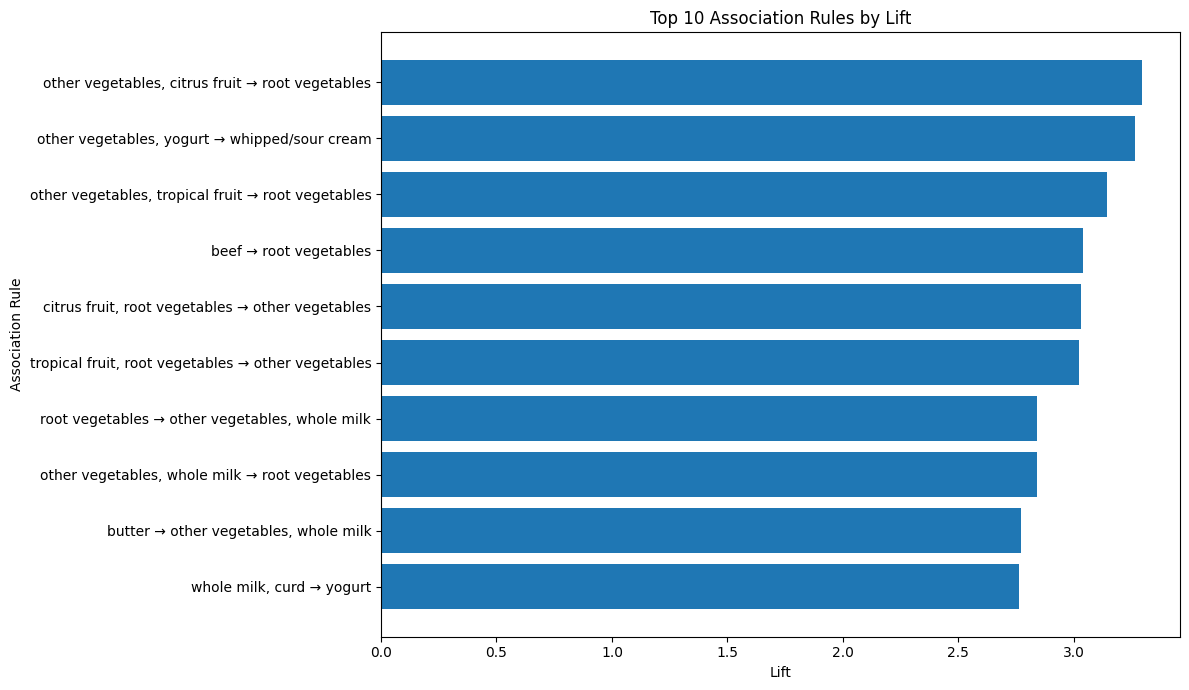

In [30]:
# Top 10 Association Rules by Lift

top_rules = rules.head(10).copy()

# Convert frozensets to readable text
top_rules["rule"] = (
    top_rules["antecedents"].apply(lambda x: ", ".join(x))
    + " → " +
    top_rules["consequents"].apply(lambda x: ", ".join(x))
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_rules["rule"],
    top_rules["lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 Association Rules by Lift")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

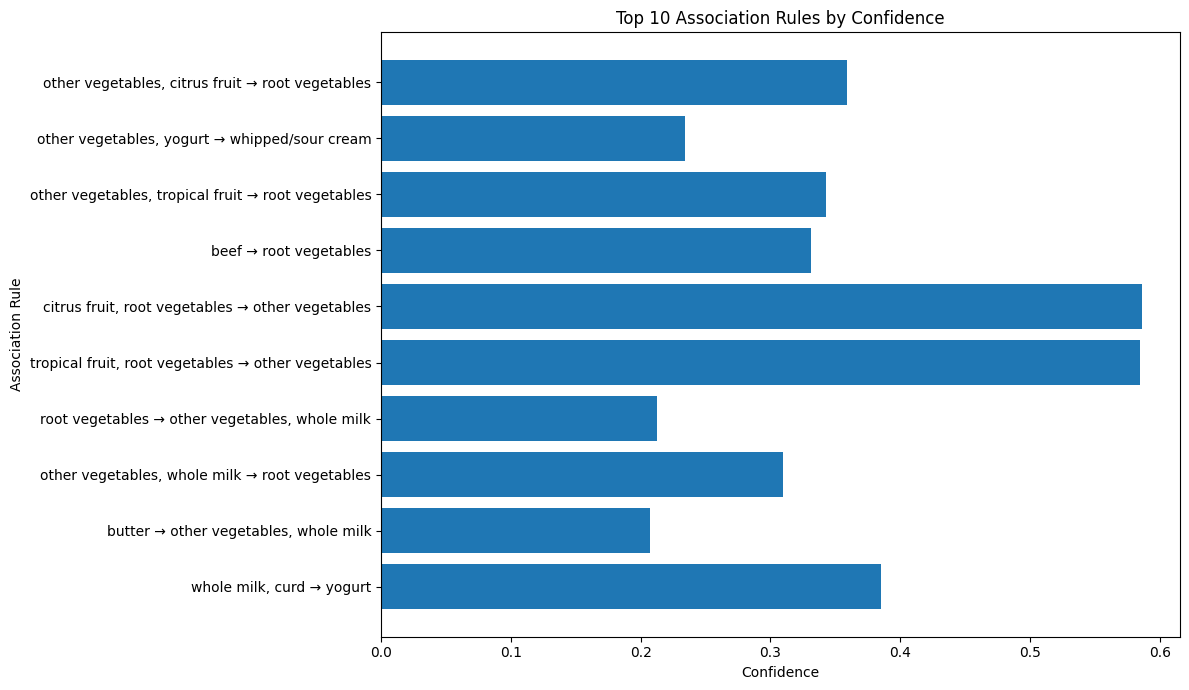

In [31]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_rules["rule"],
    top_rules["confidence"]
)

plt.xlabel("Confidence")
plt.ylabel("Association Rule")
plt.title("Top 10 Association Rules by Confidence")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Business Insights

1. The analysis identifies frequently purchased products and product combinations.

2. Association rules help identify products that are commonly purchased together.

3. Rules with lift greater than 1 indicate a positive association between the products.

4. The strongest association found in this analysis is:
   Other Vegetables + Citrus Fruit → Root Vegetables
   with a lift of approximately 3.30.

5. These associations can be used for product placement, cross-selling,
   bundle offers, and recommendation strategies.

6. Market Basket Analysis can help retailers understand customer purchasing
   patterns and improve their sales strategy.

In [32]:
# Create a clean summary table

final_rules = rules.head(10).copy()

final_rules["Antecedents"] = final_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)

final_rules["Consequents"] = final_rules["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

final_rules = final_rules[
    ["Antecedents", "Consequents", "support", "confidence", "lift"]
]

final_rules.columns = [
    "Products Bought Together",
    "Recommended Product",
    "Support",
    "Confidence",
    "Lift"
]

final_rules

,Products Bought Together,Recommended Product,Support,Confidence,Lift
0,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
1,"other vegetables, yogurt",whipped/sour cream,0.010168,0.234192,3.267062
2,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780
3,beef,root vegetables,0.017387,0.331395,3.040367
4,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
5,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999
6,root vegetables,"other vegetables, whole milk",0.023183,0.212687,2.842082
7,"other vegetables, whole milk",root vegetables,0.023183,0.309783,2.842082
8,butter,"other vegetables, whole milk",0.011490,0.207339,2.770630
9,"curd, whole milk",yogurt,0.010066,0.385214,2.761356


## Conclusion

Market Basket Analysis was performed on 9,835 grocery transactions
containing 169 unique products.

The Apriori algorithm was used to identify frequent itemsets, followed
by association rule mining using support, confidence, and lift.

The results revealed meaningful relationships between products.
These insights can help retailers improve product placement,
cross-selling, promotional offers, and recommendation systems.

Overall, the project demonstrates how transaction data can be converted
into actionable business insights using Data Analytics and Machine Learning
techniques.